In [1]:
###### import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_complexHelmholtz_dirichlet_3d"
config.target = "jmlr_docker"
config.debug_mode = True

In [2]:
import numpy as np
import probnum as pn
import linpde_gp
from linpde_gp.utils import to_real2, from_real2

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
import matplotlib.pyplot as plt
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.gridspec as gridspec

In [4]:
%matplotlib inline

In [5]:
plt.rcParams.update(config.tueplots_bundle())
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
plt.rcParams['text.usetex'] = True

In [6]:
rng = np.random.default_rng(24)

## Problem Definition

We solve the **complex-valued** inhomogeneous Helmholtz equation on $\Omega = [-1,1]^3$
with Dirichlet boundary conditions,
$$\Delta u(\mathbf{x}) + \kappa^2\, u(\mathbf{x}) = f(\mathbf{x}), \qquad u|_{\partial\Omega} = g,$$
where the squared wavenumber $\kappa^2 = \rho\,\omega^2 / (G' + \mathrm{i}\,G'')$ is **complex**
whenever the loss modulus $G'' \neq 0$. This is the 3D analogue of the 1D and 2D complex examples.

The complex field is represented in the `real2` convention $u = (\mathrm{Re}\,u,\ \mathrm{Im}\,u)$.
Splitting $\kappa^2 = \alpha + \mathrm{i}\beta$, the single complex PDE becomes the coupled real
$2\times 2$ block system
$$\begin{bmatrix}\Delta + \alpha & -\beta \\ \beta & \Delta + \alpha\end{bmatrix}
\begin{bmatrix}\mathrm{Re}\,u \\ \mathrm{Im}\,u\end{bmatrix}
=\begin{bmatrix}\mathrm{Re}\,f \\ \mathrm{Im}\,f\end{bmatrix},$$
which `HelmholtzReal2Operator` builds. The Laplacian is dimension-agnostic, so the construction is
identical to 1D and 2D — only the domain (now a 3D box) changes.

In [7]:
rho, omega, Gp, Gpp = 1.0, 1.0, 1.0, 0.5  # Gpp != 0 => complex kappa^2

In [8]:
bvp = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=linpde_gp.domains.Box([[-1.0, 1.0], [-1.0, 1.0], [-1.0, 1.0]]),
    rho=rho,
    omega=omega,
    G_real=Gp,
    G_imag=Gpp,
    rhs=linpde_gp.functions.Constant(input_shape=(3,), value=to_real2(2.0 + 0.0j)),
    boundary_values=linpde_gp.functions.Constant(input_shape=(3,), value=to_real2(0.0)),
    complex_representation="real2",
)
print("kappa^2 =", bvp.pde.k_squared)
print("operator:", type(bvp.pde.diffop).__name__)

kappa^2 = (0.8-0.4j)
operator: HelmholtzReal2Operator


In [9]:
k2 = complex(bvp.pde.k_squared)
k = np.sqrt(k2)
print(f"Squared wavenumber kappa^2: {k2:.4f}")
print(f"Wavenumber kappa: {k:.4f}")
print(f"Wavelength lambda = 2*pi/Re(kappa): {2*np.pi/np.real(k):.4f}")

Squared wavenumber kappa^2: 0.8000-0.4000j
Wavenumber kappa: 0.9204-0.2173j
Wavelength lambda = 2*pi/Re(kappa): 6.8263


## GP Prior

The prior places an independent, identically-scaled GP on the real and imaginary parts via
`Real2FromScalarKernel`, which wraps the scalar 3D tensor-product `ExpQuad` kernel into a
block-diagonal $(\mathrm{Re}, \mathrm{Im})$ kernel. This is exactly the 1D/2D construction with a
3D base kernel.

In [10]:
prior_gp = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=(3,), output_shape=(2,)),
    cov=linpde_gp.randprocs.covfuncs.Real2FromScalarKernel(
        2.0 ** 2 * linpde_gp.randprocs.covfuncs.TensorProduct(
            linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
            linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
            linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
        )
    ),
)

## Boundary Conditions

**Note on the noise model (the one `real2`-specific subtlety).** Exactly as in the real-valued
example, each observation gets a small jitter term `b` for numerical stability (a dense boundary
grid is otherwise near-singular, and the jitter also lets us evaluate the posterior *covariance*,
not just the mean).

There is one bookkeeping detail unique to the vector-valued `real2` GP. For a batch of `N` points
the measurement output is `(2, N)`, and `probnum.randvars.Normal` only supports jitter covariances
up to 2-D. So we pass each face as a **flat** `(N, 3)` batch (rather than an `(N_x, N_y)` grid,
whose measurement output `(2, N_x, N_y)` would be a 3-axis tensor that `Normal` cannot represent).
Flattening keeps the jitter valid for both the boundary and the PDE constraints. This is purely a
shape convention — the model is identical to the real-valued 3D example.

In [11]:
def _normalize_real2_xy(X, Y, d=3):
    """Flatten boundary/collocation points to (N, d) and real2 targets to (N, 2)."""
    X = np.asarray(X).reshape(-1, d)
    Y = np.asarray(Y).reshape(-1, 2)
    return X, Y


N_bc_face = 12
bc_jitter = 1e-6  # regularizes the (otherwise near-singular) boundary Gram
u_bc = prior_gp
X_bc_list = []

for i, boundary_condition in enumerate(bvp.boundary_conditions):
    X_bc = boundary_condition.boundary.uniform_grid((N_bc_face, N_bc_face), inset=1e-4)
    Y_bc = boundary_condition.values(X_bc)          # real2 -> (N, 2)
    X_bc, Y_bc = _normalize_real2_xy(X_bc, Y_bc, d=3)
    X_bc_list.append(X_bc)

    n_bc = X_bc.shape[0]
    assert X_bc.shape == (N_bc_face ** 2, 3)
    assert Y_bc.shape == (N_bc_face ** 2, 2)
    print(f"  Face {i+1}: {n_bc} points")

    # BC measurement output is shaped (2, n_bc) -> a 2D Normal jitter is valid here.
    b_bc = pn.randvars.Normal(
        mean=np.zeros((2, n_bc)),
        cov=bc_jitter * np.eye(2 * n_bc),
    )
    u_bc = u_bc.condition_on_observations(Y=Y_bc, X=X_bc, b=b_bc)

  Face 1: 144 points
  Face 2: 144 points
  Face 3: 144 points
  Face 4: 144 points
  Face 5: 144 points
  Face 6: 144 points


### Conditioning on the PDE

In [12]:
N_pde = 9
pde_jitter = 1e-4  # stabilizes the joint Gram so the posterior covariance is available

print(f"\nConditioning on PDE with {N_pde}³ = {N_pde**3} interior points...")

# Flat (N_pde^3, 3) batch of collocation points -> measurement output is (2, N) (2-D),
# which keeps the Normal jitter valid (see the note above).
X_pde = np.asarray(bvp.domain.uniform_grid((N_pde, N_pde, N_pde), inset=1e-6)).reshape(-1, 3)
Y_pde = np.asarray(bvp.pde.rhs(X_pde))  # (N_pde^3, 2) real2
n_pde = X_pde.shape[0]

b_pde = pn.randvars.Normal(
    mean=np.zeros((2, n_pde)),
    cov=pde_jitter * np.eye(2 * n_pde),
)

u_bc_pde = u_bc.condition_on_observations(
    Y=Y_pde,
    L=bvp.pde.diffop,
    X=X_pde,
    b=b_pde,
)


Conditioning on PDE with 9³ = 729 interior points...


In [13]:
print("Y_pde shape (real2 targets):", Y_pde.shape)

Y_pde shape (real2 targets): (729, 2)


## Visualization

We keep the multi-plane slice style of the real-valued 3D example: each column is an
axial slice $x_3 = \text{const}$, mean panels use `plasma` and $1.96\,\sigma$ credible
half-widths use `viridis`, with the domain outline and observation overlays drawn in white.
The only change for the complex field is that the two-row (mean, uncertainty) layout is
**stacked twice**, giving four rows: the real part on top (**a**, **b**) and the imaginary
part below (**c**, **d**).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

def _points_near_slice(pts, z_val, atol):
    pts = np.asarray(pts).reshape(-1, 3)
    mask = np.abs(pts[:, 2] - z_val) < atol
    return pts[mask]

def plot_multiplane_slices_complex(
    u_post, bvp,
    z_slices=(-0.50, 0.0, 0.50),
    resolution=50,
    X_pde=None, X_bc_list=None,
    extent=(-1, 1, -1, 1),
    figsize=(5.5, 7.2),
    slice_tol=None,
    show_domain_outline=True,
):
    """Multi-plane z-slices of a complex (real2) posterior.

    Same visual language as the real-valued 3D example (plasma mean panels,
    viridis 1.96 sigma panels, white domain outline + observation overlays),
    stacked into four rows: Re mean, Re 1.96 sigma, Im mean, Im 1.96 sigma.
    Columns are the z-slices x_3 = const.
    """
    n_slices = len(z_slices)

    x = np.linspace(extent[0], extent[1], resolution)
    y = np.linspace(extent[2], extent[3], resolution)
    xx, yy = np.meshgrid(x, y, indexing="ij")

    # means/cis per slice, each a real2 pair -> store [Re, Im]
    means_re, means_im, cis_re, cis_im = [], [], [], []
    for z_val in z_slices:
        grid = np.stack([xx, yy, np.full_like(xx, z_val)], axis=-1)
        X_flat = grid.reshape(-1, 3)

        u_mean = np.asarray(u_post.mean(grid)).reshape(resolution, resolution, 2)
        with np.errstate(invalid="ignore"):
            u_std = np.asarray(u_post.std(X_flat)).reshape(resolution, resolution, 2)
        u_std = np.maximum(np.nan_to_num(u_std, nan=0.0), 0.0)

        means_re.append(u_mean[..., 0]); means_im.append(u_mean[..., 1])
        cis_re.append(1.96 * u_std[..., 0]); cis_im.append(1.96 * u_std[..., 1])

    # Shared color scales (per quantity, across slices)
    vmin_mre = min(m.min() for m in means_re); vmax_mre = max(m.max() for m in means_re)
    vmin_mim = min(m.min() for m in means_im); vmax_mim = max(m.max() for m in means_im)
    vmax_cre = max(c.max() for c in cis_re); vmax_cim = max(c.max() for c in cis_im)

    X_pde_flat = np.asarray(X_pde).reshape(-1, 3) if X_pde is not None else None
    X_bc_all = (
        np.concatenate([np.asarray(xb).reshape(-1, 3) for xb in X_bc_list], axis=0)
        if X_bc_list is not None else None
    )

    if slice_tol is None and X_pde_flat is not None:
        unique_z = np.unique(np.round(X_pde_flat[:, 2], 10))
        slice_tol = 0.5 * np.min(np.diff(np.sort(unique_z))) if len(unique_z) > 1 else 0.15
    elif slice_tol is None:
        slice_tol = 0.15

    # 4 rows: Re mean, Re ci, Im mean, Im ci
    row_data = [means_re, cis_re, means_im, cis_im]
    row_cmap = ["plasma", "viridis", "plasma", "viridis"]
    row_vlim = [(vmin_mre, vmax_mre), (0, vmax_cre), (vmin_mim, vmax_mim), (0, vmax_cim)]
    row_cbar = [
        r"$\mathrm{Re}\,\mathbb{E}[u \mid \mathcal{I}]$",
        r"$1.96\,\sigma[\mathrm{Re}\,u \mid \mathcal{I}]$",
        r"$\mathrm{Im}\,\mathbb{E}[u \mid \mathcal{I}]$",
        r"$1.96\,\sigma[\mathrm{Im}\,u \mid \mathcal{I}]$",
    ]
    panel_letters = ["a", "b", "c", "d"]

    fig, axes = plt.subplots(4, n_slices, figsize=figsize, constrained_layout=True)
    if n_slices == 1:
        axes = axes[:, np.newaxis]

    ims = [None] * 4
    for r in range(4):
        data = row_data[r]; vmin, vmax = row_vlim[r]
        for j, z_val in enumerate(z_slices):
            ax = axes[r, j]
            ims[r] = ax.imshow(
                data[j].T, cmap=row_cmap[r], extent=extent, origin="lower",
                aspect="equal", interpolation="bilinear", vmin=vmin, vmax=vmax,
            )
            # observation overlays
            if X_pde_flat is not None:
                pts = _points_near_slice(X_pde_flat, z_val, slice_tol)
                if len(pts):
                    ax.scatter(pts[:, 0], pts[:, 1], s=4, c="black",
                               alpha=0.35, linewidth=0, marker="o")
            if X_bc_all is not None:
                pts = _points_near_slice(X_bc_all, z_val, slice_tol)
                if len(pts):
                    ax.scatter(pts[:, 0], pts[:, 1], s=12, c="black",
                               alpha=0.55, linewidth=0.8, marker="x")
            if show_domain_outline:
                ax.add_patch(patches.Rectangle(
                    (extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2],
                    linewidth=1.0, edgecolor="white", facecolor="none", alpha=0.7,
                ))
            if r == 0:
                ax.set_title(rf"$x_3 = {z_val:+.2f}$", fontsize=9)
            if r == 3:
                ax.set_xlabel(r"$x_1$")
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(r"$x_2$")
            else:
                ax.set_yticklabels([])
        # row panel letter
        axes[r, 0].text(-0.02, 1.02, rf"\textbf{{{panel_letters[r]}}}",
                        transform=axes[r, 0].transAxes, fontsize=11,
                        fontweight="bold", va="bottom", ha="right")
        # shared colorbar for the row
        cbar = fig.colorbar(ims[r], ax=axes[r, :].tolist(), fraction=0.025, pad=0.02)
        cbar.set_label(row_cbar[r])

    # conditioning-info annotation on the top-left mean panel
    cond_parts = []
    if X_bc_list is not None:
        cond_parts.append(r"$u|_{\partial \Omega} = g$")
    if X_pde is not None:
        k2 = complex(bvp.pde.k_squared)
        k2s = rf"{k2.real:.2f}{k2.imag:+.2f}\,\mathrm{{i}}"
        cond_parts.append(rf"$(\Delta + ({k2s}))\,u(\mathbf{{x}}_i) = f(\mathbf{{x}}_i)$")
    if cond_parts:
        cond_text = r"$\mathcal{I}$: " + r",\;".join(cond_parts)
        axes[0, 0].text(
            0.03, 0.97, cond_text, transform=axes[0, 0].transAxes, fontsize=5.0,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      alpha=0.6, edgecolor="gray", linewidth=0.3),
        )
    return fig

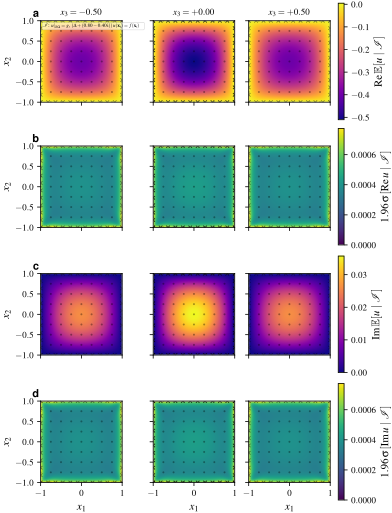

In [15]:
fig = plot_multiplane_slices_complex(
    u_bc_pde, bvp,
    z_slices=(-0.50, 0.0, 0.50),
    resolution=50,
    X_pde=X_pde,
    X_bc_list=X_bc_list,
)
fig.savefig('./helmholtz3d_complex_posterior_729pts.pdf', bbox_inches='tight')
plt.show()

## Evaluation against the analytical complex solution

For a constant complex source $f$ on $[-1,1]^3$ with homogeneous Dirichlet data, the solution
admits a triple sine eigenfunction expansion. The series coefficients carry the complex $\kappa^2$
through $(-\lambda_{mnp} + \kappa^2)^{-1}$, so the same routine used for the real case returns a
complex field when given a complex $\kappa^2$.

In [ ]:
def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=51, N=51, P=51):
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    C = 2.0
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2 + (np.pi * p / 2) ** 2
                denom = -lam + k_squared
                f_coeff = C * (4.0 / np.pi) ** 3 / (m * n * p)
                u_coeff = f_coeff / denom
                u += u_coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)
    return u


nx, ny, nz = 21, 21, 21
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

pts = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

# Complex (real2) posterior mean -> complex field on the grid.
# (The only difference from the real-valued case: the mean is (N, 2) = [Re, Im],
#  which we recombine into a complex field. The metric definitions below are
#  identical -- they already use np.abs(diff), which handles the complex error.)
pred_real2 = u_bc_pde.mean(pts)                        # (N, 2)
u_pred = (pred_real2[:, 0] + 1j * pred_real2[:, 1]).reshape(nx, ny, nz)

k2 = bvp.pde.k_squared
u_true = analytical_constant_source_3d(X, Y, Z, k_squared=k2, M=51, N=51, P=51)

diff = u_true - u_pred

metrics = {
    "mse": float(np.mean(np.abs(diff) ** 2)),
    "rmse": float(np.sqrt(np.mean(np.abs(diff) ** 2))),
    "mae": float(np.mean(np.abs(diff))),
    "max_error": float(np.max(np.abs(diff))),
    "relative_l2": float(np.linalg.norm(diff) / np.linalg.norm(u_true)),
}

print("\nEvaluation Metrics (on 21×21×21 grid):")
print("-" * 40)
for name, value in metrics.items():
    print(f"  {name.upper():15s}: {value:.6e}")

print(f"\n  Solution range (GP, Re): [{np.min(u_pred.real):.4f}, {np.max(u_pred.real):.4f}]")
print(f"  Solution range (GP, Im): [{np.min(u_pred.imag):.4f}, {np.max(u_pred.imag):.4f}]")


# --- per-component breakdown (shared with the FDM / PINN notebooks) ---
def _metrics(pred, true):
    pred = np.asarray(pred).ravel(); true = np.asarray(true).ravel()
    err = np.abs(pred - true); denom = np.linalg.norm(true)
    return {
        "mse": float(np.mean(err ** 2)),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(err)),
        "max_error": float(np.max(err)),
        "relative_l2": float(np.linalg.norm(err) / denom) if denom > 0 else np.inf,
    }

def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    MAE:                 {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    MSE:                 {m['mse']:12.6e}")

print("\n" + "=" * 60)
print("PER-COMPONENT METRICS - Complex Helmholtz 3D (LinPDE-GP)".center(60))
print(f"  Grid: {nx}x{ny}x{nz}   kappa^2 = {complex(k2):.4f}")
print(f"  N_col = {N_pde}^3 = {N_pde ** 3} interior collocation points")
print("=" * 60)
_print_block("Real Part", _metrics(u_pred.real, u_true.real))
_print_block("Imaginary Part", _metrics(u_pred.imag, u_true.imag))
_print_block("Complex |u|", _metrics(u_pred, u_true))
print("\n" + "=" * 60)
